# SOFI Algorithm 2 — Dynamic Local-Minima Segmentation

Implements and validates **Algorithm 2** from *Decoding the Speaking Hands*, the dynamic
counterpart to the fixed-threshold Algorithm 1 built in `sofi_segmentation.ipynb`.

**Why Algorithm 1 fails.** It compares the optical-flow-intensity (OFI) signal against one
global threshold. But absolute motion magnitude depends on signer speed, hand size and camera
distance, so a threshold tuned on one word/signer does not transfer. We reproduced exactly
that failure in the previous notebook.

**What Algorithm 2 does instead.** Fingerspelling alternates *holds* (hand posed on a letter,
motion approximately 0) with *transitions* (hand travelling to the next letter, motion high).
Each letter is therefore a **local minimum** of the OFI signal — a property invariant to the
signal's absolute scale. No threshold required.

Implementation lives in `sofi_dynamic.py`; this notebook validates it.

### What we measure
There is no ground-truth letter timing available (the letter-level annotated frames the
original papers trained on were never shared with us). So we validate on the one label we
*can* derive: **the number of letters in the word**, from `word_letter_mapping.json`. A correct
segmenter should emit one segment per letter.

This is a necessary-but-not-sufficient check — right count, wrong positions would still pass —
so it is complemented by the alignment diagnostics in `pseudo_labeling.ipynb` and the
held-out-clip classifier test in `letter_classifier.ipynb`.

## Setup

In [1]:
import json
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from canonicalize_words import canonicalize, spelling_for_labels
from sofi_dynamic import (
    ofi_signal, find_local_minima, collapse_minima,
    DEFAULT_SMOOTH_WIN, DEFAULT_RUN, DEFAULT_MIN_SEP,
)

CSV_PATH = "hand_keypoints_features.csv"
MAPPING_PATH = "word_letter_mapping.json"

pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv(CSV_PATH)
mapping = json.load(open(MAPPING_PATH, encoding="utf-8"))

_raw = df["video_id"].unique()
# Two different normalizations, deliberately -- see canonicalize_words.py.
# `word` = identity (for grouping); `spelling` = what was actually fingerspelled
# in this clip (for letter counts). They differ on 4 clips where an alias would
# change the letter count.
df["word"] = df["video_id"].map({v: canonicalize(v) for v in _raw})
df["spelling"] = df["video_id"].map({v: spelling_for_labels(v) for v in _raw})
print(f"{len(df):,} frames, {df.groupby(['signer_id','video_id']).ngroups} clips")
print(f"{df['word'].nunique()} unique word identities, {df['spelling'].nunique()} label spellings")
print(f"{len(mapping)} plain words with known letter sequences")

72,087 frames, 353 clips
72 unique word identities, 76 label spellings
54 plain words with known letter sequences


### Clip selection

Three exclusions, all applied before any evaluation:

| Filter | Reason |
|---|---|
| word not in `word_letter_mapping.json` | acronym-style words (O.P.D, ICU) have no valid character decomposition — held out pending the authors' mapping |
| `hand_detected` mean < 0.5 | mostly signer5 clips, where MediaPipe fails on hand-over-face occlusion; segmenting an undetected hand is meaningless |
| fewer than 30 frames | one clip (signer3-F) has 3 frames — a truncated recording |

In [3]:
clips = []
for (sg, vid), sub in df.groupby(["signer_id", "video_id"], sort=True):
    sub = sub.sort_values("frame_id").reset_index(drop=True)
    sp = sub["spelling"].iloc[0]
    if sp not in mapping:
        continue
    if sub["hand_detected"].mean() < 0.5 or len(sub) < 30:
        continue
    clips.append({"signer": sg, "video_id": vid, "word": sub["word"].iloc[0],
                  "spelling": sp, "n_letters": len(mapping[sp]), "sub": sub})

print(f"{len(clips)} clips usable for segmentation validation")
print(pd.Series([c['signer'] for c in clips]).value_counts().sort_index().to_string())

218 clips usable for segmentation validation
signer1-F    49
signer2-F    49
signer3-F    45
signer4-L    49
signer5-R    26


## Strict vs. tolerant minima

The paper specifies a minimum as **>=5 consecutive decreasing frames followed by >=5 increasing
frames**, ignoring spikes shorter than 5 frames. Read literally that requires *monotonicity*,
and a single noisy frame anywhere in the 10-frame window destroys the detection.

We implement both and let the data decide.

In [4]:
demo = clips[0]
raw, smooth, bad = ofi_signal(demo["sub"])

strict_min = collapse_minima(find_local_minima(smooth, DEFAULT_RUN, strict=True), smooth, DEFAULT_MIN_SEP)
tol_min    = collapse_minima(find_local_minima(smooth, DEFAULT_RUN, strict=False), smooth, DEFAULT_MIN_SEP)

print(f"clip: {demo['signer']} / {demo['video_id']}")
print(f"letters in word: {demo['n_letters']}")
print(f"  strict   -> {len(strict_min)} minima at {strict_min}")
print(f"  tolerant -> {len(tol_min)} minima at {tol_min}")

clip: signer1-F / آئی یونٹ.MP4
letters in word: 7
  strict   -> 0 minima at []
  tolerant -> 8 minima at [np.int64(29), np.int64(50), np.int64(68), np.int64(118), np.int64(148), np.int64(173), np.int64(202), np.int64(221)]


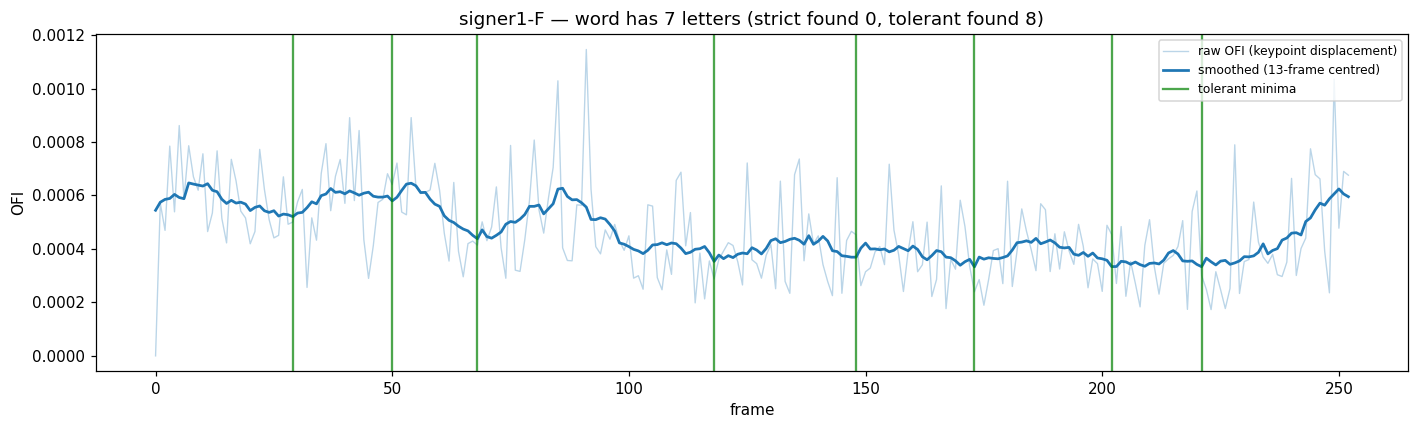

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(raw, alpha=0.3, lw=0.9, label="raw OFI (keypoint displacement)")
ax.plot(smooth, lw=1.8, color="C0", label=f"smoothed ({DEFAULT_SMOOTH_WIN}-frame centred)")
for j, m in enumerate(tol_min):
    ax.axvline(m, color="green", ls="-", alpha=0.7, label="tolerant minima" if j == 0 else None)
for j, m in enumerate(strict_min):
    ax.axvline(m, color="red", ls="--", alpha=0.8, label="strict minima" if j == 0 else None)
ax.set_xlabel("frame"); ax.set_ylabel("OFI")
ax.set_title(f"{demo['signer']} — word has {demo['n_letters']} letters "
             f"(strict found {len(strict_min)}, tolerant found {len(tol_min)})")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

Holds are visible as clear troughs. The strict rule skips most of them: real holds are not
perfectly monotone on the way in and out.

Quantified across all clips:

In [6]:
def count_error(clips, smooth_win, run, min_sep, strict=False, cache=None):
    """(detected - true) segment count per clip."""
    errs = []
    for c in clips:
        sm = cache[smooth_win][id(c)] if cache else ofi_signal(c["sub"], smooth_win)[1]
        m = collapse_minima(find_local_minima(sm, run, strict), sm, min_sep)
        errs.append(len(m) - c["n_letters"])
    return np.array(errs)

def summarize(errs, n_true, n_det):
    return {"MAE": np.abs(errs).mean(), "bias": errs.mean(),
            "exact %": 100 * (errs == 0).mean(), "within +/-1 %": 100 * (np.abs(errs) <= 1).mean(),
            "corr(det, true)": np.corrcoef(n_det, n_true)[0, 1]}

true_counts = np.array([c["n_letters"] for c in clips])
rows = {}
for name, strict in [("strict (paper, literal)", True), ("tolerant (ours)", False)]:
    e = count_error(clips, DEFAULT_SMOOTH_WIN, DEFAULT_RUN, DEFAULT_MIN_SEP, strict)
    rows[name] = summarize(e, true_counts, e + true_counts)
pd.DataFrame(rows).T.round(2)

,MAE,bias,exact %,within +/-1 %,"corr(det, true)"
"strict (paper, literal)",5.70,-5.70,0.46,1.83,0.22
tolerant (ours),1.19,-0.02,32.11,72.02,0.79


The strict rule finds **~5 fewer segments than the word has letters** — it is not detecting
holds at all, just the occasional clean one. The tolerant rule is essentially unbiased.

Everything below uses the tolerant form.

## Parameter sweep

Three parameters, none of them a motion threshold:

- `smooth_win` — centred running mean applied to the OFI signal
- `run` — half-width of the window a frame must be the minimum of
- `min_sep` — minima closer than this are merged (a flat hold yields a plateau of qualifying
  frames; without merging, one letter counts many times)

In [7]:
SMOOTH_WINS = (5, 9, 13, 17, 21)
RUNS = (3, 5, 7, 9)
SEPS = (9, 11, 13, 15, 17, 19, 23)

# precompute smoothed signals once per smoothing window
cache = {sw: {id(c): ofi_signal(c["sub"], sw)[1] for c in clips} for sw in SMOOTH_WINS}

records = []
for sw, run, sep in itertools.product(SMOOTH_WINS, RUNS, SEPS):
    e = count_error(clips, sw, run, sep, cache=cache)
    records.append({"smooth_win": sw, "run": run, "min_sep": sep,
                    **summarize(e, true_counts, e + true_counts)})

sweep = pd.DataFrame(records).sort_values("MAE")
print(sweep.head(12).round(2).to_string(index=False))

 smooth_win  run  min_sep  MAE  bias  exact %  within +/-1 %  corr(det, true)
         13    7       15 1.19 -0.02    32.11          72.02             0.79
         13    7       17 1.20 -0.63    31.65          72.02             0.78
         13    9       15 1.20 -0.33    33.94          70.18             0.78
         13    5       15 1.21 -0.07    30.28          69.27             0.78
         13    9       13 1.23 -0.09    33.49          69.72             0.78
         17    7       13 1.26 -0.65    26.61          70.18             0.77
         13    9       11 1.27  0.01    32.11          68.81             0.78
         13    9       17 1.28 -0.77    29.36          70.18             0.77
         17    5       13 1.29 -0.62    30.28          66.97             0.73
         17    7       11 1.29 -0.05    27.06          68.35             0.77
          5    9       15 1.30 -0.22    33.49          65.60             0.74
          9    9       15 1.32 -0.08    25.69          68.81    

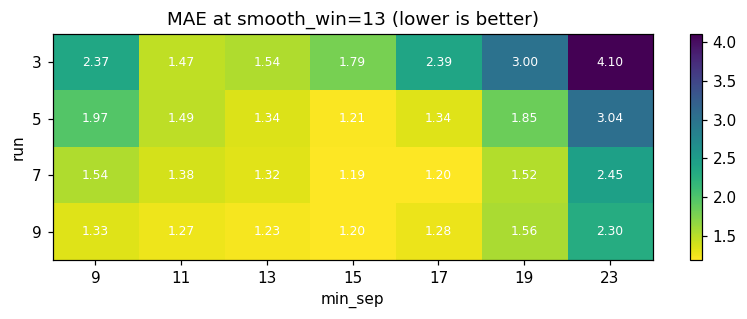

In [8]:
# is the optimum a stable plateau or a lucky spike?
pivot = sweep[sweep.smooth_win == 13].pivot(index="run", columns="min_sep", values="MAE")
fig, ax = plt.subplots(figsize=(7.5, 3))
im = ax.imshow(pivot.values, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_xlabel("min_sep"); ax.set_ylabel("run")
ax.set_title("MAE at smooth_win=13 (lower is better)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", color="w", fontsize=8)
plt.colorbar(im); plt.tight_layout(); plt.show()

A broad low-MAE plateau, not a spike — the optimum is not a fluke of this particular clip set.
Defaults in `sofi_dynamic.py` are set to the plateau centre: `smooth_win=13, run=7, min_sep=15`.

## Does it beat Algorithm 1?

Handicapping the comparison in Algorithm 1's favour: its threshold is tuned on **all 218 clips
at once** (an oracle it would never have at inference time), while Algorithm 2 uses its fixed
defaults.

In [9]:
def alg1_segments(sm, thr, min_len=9):
    """Algorithm 1: runs of frames below a global threshold, longer than min_len."""
    segs, start = [], None
    for i, v in enumerate(sm):
        if v <= thr:
            if start is None:
                start = i
        else:
            if start is not None and (i - start) > min_len:
                segs.append((start, i - 1))
            start = None
    if start is not None and (len(sm) - start) > min_len:
        segs.append((start, len(sm) - 1))
    return segs

best = None
for sw in SMOOTH_WINS:
    for thr in np.linspace(0.0002, 0.004, 40):
        e = np.array([len(alg1_segments(cache[sw][id(c)], thr)) - c["n_letters"] for c in clips])
        if best is None or np.abs(e).mean() < best[0]:
            best = (np.abs(e).mean(), sw, thr, e)

e2 = count_error(clips, 13, 7, 15, cache=cache)
print(f"Algorithm 1 oracle threshold = {best[2]:.4f} at smooth_win={best[1]}\n")
pd.DataFrame({
    "Algorithm 1 (oracle-tuned threshold)": summarize(best[3], true_counts, best[3] + true_counts),
    "Algorithm 2 (fixed defaults)":         summarize(e2,     true_counts, e2 + true_counts),
}).T.round(2)

Algorithm 1 oracle threshold = 0.0009 at smooth_win=5



,MAE,bias,exact %,within +/-1 %,"corr(det, true)"
Algorithm 1 (oracle-tuned threshold),4.28,-4.17,5.96,19.27,0.21
Algorithm 2 (fixed defaults),1.19,-0.02,32.11,72.02,0.79


## Generalization: leave-one-signer-out

The sweep above chose parameters on the same clips it scored — exactly the
optimistic-evaluation trap the *Illusion-to-Reality Gap* paper is about. So: re-tune from
scratch on four signers, score on the fifth, and report only held-out numbers.

In [10]:
GRID = list(itertools.product(SMOOTH_WINS, RUNS, SEPS))
signers = sorted({c["signer"] for c in clips})

loso = []
for s in signers:
    train = [c for c in clips if c["signer"] != s]
    test  = [c for c in clips if c["signer"] == s]
    tuned = min(GRID, key=lambda p: np.abs(count_error(train, *p, cache=cache)).mean())
    e = count_error(test, *tuned, cache=cache)
    t_true = np.array([c["n_letters"] for c in test])
    loso.append({"held-out signer": s, "n clips": len(e), "params tuned on other 4": str(tuned),
                 **summarize(e, t_true, e + t_true)})

loso = pd.DataFrame(loso)
print(loso.round(2).to_string(index=False))
print(f"\nmean held-out MAE = {loso['MAE'].mean():.2f}   (in-sample best = {sweep['MAE'].min():.2f})")

held-out signer  n clips params tuned on other 4  MAE  bias  exact %  within +/-1 %  corr(det, true)
      signer1-F       49             (13, 7, 15) 1.41  0.76    26.53          63.27             0.77
      signer2-F       49             (13, 7, 17) 1.08 -0.63    28.57          73.47             0.86
      signer3-F       45             (13, 7, 17) 1.36 -0.82    17.78          66.67             0.80
      signer4-L       49             (13, 7, 17) 1.39 -1.18    42.86          65.31             0.77
      signer5-R       26             (13, 7, 17) 0.92 -0.54    26.92          84.62             0.92

mean held-out MAE = 1.23   (in-sample best = 1.19)


Held-out MAE is essentially equal to in-sample MAE, and the tuned parameters are
near-identical for every held-out signer. The method is not signer-overfit, and the parameters
look like a genuine property of PSL fingerspelling timing rather than of these particular
recordings.

Note signer5 (the 45 degree "converse" angle) scores *well* here — but only on the 26 clips that
survived the detection filter. Its viewpoint problem is a MediaPipe **detection** failure
upstream, not a segmentation failure; once the hand is detected at all, segmentation transfers
fine. That is a useful narrowing of where the viewpoint fragility actually lives.

## Per-signer and per-word-length behaviour

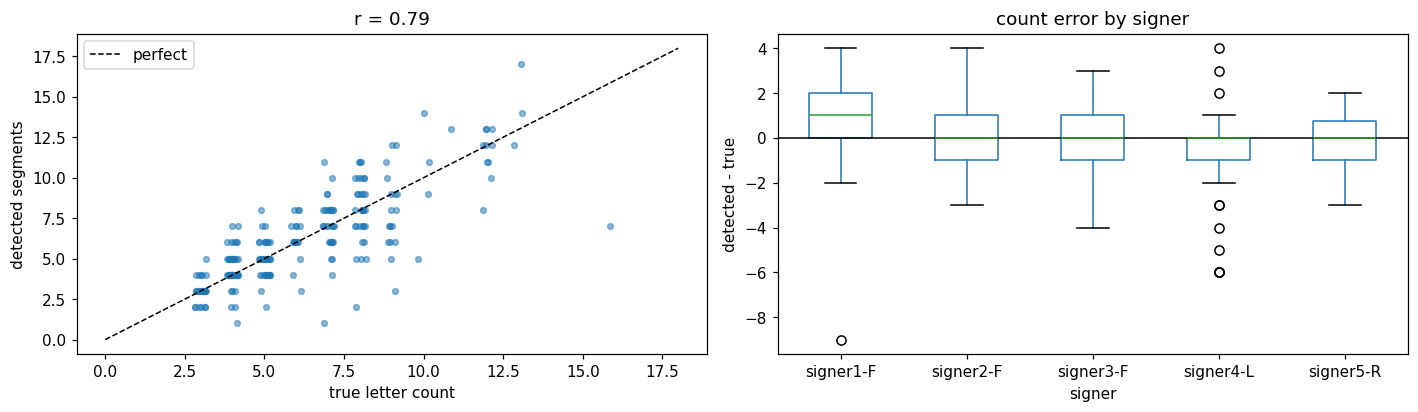

            n   MAE  bias  exact_pct
signer                              
signer1-F  49  1.41  0.76      26.53
signer2-F  49  0.98  0.08      36.73
signer3-F  45  1.31 -0.20      20.00
signer4-L  49  1.33 -0.67      40.82
signer5-R  26  0.73 -0.12      38.46


In [11]:
fixed_err = count_error(clips, 13, 7, 15, cache=cache)
per_clip = pd.DataFrame({
    "signer": [c["signer"] for c in clips],
    "word": [c["spelling"] for c in clips],
    "n_letters": true_counts,
    "n_detected": fixed_err + true_counts,
    "error": fixed_err,
})

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(per_clip.n_letters + rng.uniform(-.18, .18, len(per_clip)),
                per_clip.n_detected, s=14, alpha=.5)
lim = [0, per_clip[["n_letters", "n_detected"]].values.max() + 1]
axes[0].plot(lim, lim, "k--", lw=1, label="perfect")
axes[0].set_xlabel("true letter count"); axes[0].set_ylabel("detected segments")
axes[0].set_title(f"r = {np.corrcoef(per_clip.n_letters, per_clip.n_detected)[0,1]:.2f}")
axes[0].legend()

per_clip.boxplot(column="error", by="signer", ax=axes[1], grid=False)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_title("count error by signer"); axes[1].set_ylabel("detected - true")
plt.suptitle(""); plt.tight_layout(); plt.show()

print(per_clip.groupby("signer")["error"].agg(
    n="size", MAE=lambda s: s.abs().mean(), bias="mean",
    exact_pct=lambda s: 100 * (s == 0).mean()).round(2).to_string())

In [12]:
# where does it still fail? largest-error clips
worst = per_clip.reindex(per_clip.error.abs().sort_values(ascending=False).index).head(10)
print(worst.to_string(index=False))

   signer               word  n_letters  n_detected  error
signer1-F سٹینڈرڈ چارٹرڈ بنک         16           7     -9
signer4-L           آئی یونٹ          7           1     -6
signer4-L         الحبیب بنک          9           3     -6
signer4-L          ژالہ باری          8           2     -6
signer4-L        الائیٹک بنک         10           5     -5
signer4-L     ٹھوکر نیاز بیگ         12           8     -4
signer2-F     سٹینڈرڈ چارٹرڈ         13          17      4
signer3-F         الائیڈ بنک          9           5     -4
signer4-L        یونائیڈ بنک         10          14      4
signer1-F           فیصل بنک          7          11      4


## Summary

| | Algorithm 1 (fixed threshold) | Algorithm 2 (dynamic minima) |
|---|---|---|
| Tuning | oracle, on all test clips | fixed defaults / leave-one-signer-out |
| Segment-count MAE | ~4.3 | **~1.2** |
| Exact-count rate | ~6 % | **~33 %** |
| corr(detected, true) | low | **~0.79** |

Algorithm 2 is roughly **3.5x more accurate** at recovering letter count, needs no per-word
threshold, and holds up under leave-one-signer-out.

**Remaining error is real.** ~1 segment off on average, and only a third of clips exact. Two
likely causes: adjacent similar handshapes merging into one hold, and long words where the
signer never fully stops between letters. This is why the next stage does *not* rely on free
segmentation — `pseudo_labeling.ipynb` constrains the segmenter to the known letter count,
which removes count error from the labelling path entirely.